In [1]:
import os
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import (
    Input, Conv2D, BatchNormalization, Activation, MaxPooling2D,
    Conv2DTranspose, concatenate, Dropout
)
from tensorflow.keras.optimizers import Adam

K.clear_session()

# ------------------------------------------------------------
# Metrics / losses
# ------------------------------------------------------------
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    intersection = tf.reduce_sum(y_true * y_pred, axis=[1, 2])
    union = tf.reduce_sum(y_true + y_pred, axis=[1, 2])
    dice = (2.0 * intersection + smooth) / (union + smooth)
    return tf.reduce_mean(dice)

def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)

def combined_loss(y_true, y_pred):
    ce = tf.keras.losses.categorical_crossentropy(y_true, y_pred)
    ce = tf.reduce_mean(ce)
    return ce + dice_loss(y_true, y_pred)


# ------------------------------------------------------------
# U-Net blocks
# ------------------------------------------------------------
def conv_block(x, filters, n_conv=2, dropout_rate=0.0):
    for _ in range(n_conv):
        x = Conv2D(filters, (3, 3), padding="same")(x)
        x = BatchNormalization()(x)
        x = Activation("relu")(x)
    if dropout_rate > 0:
        x = Dropout(dropout_rate)(x)
    return x


# ------------------------------------------------------------
# ORIGINAL architecture
# Must match the architecture used when the file was saved
# ------------------------------------------------------------
def unet(num_classes, input_shape=(512, 512, 3), lr_init=1e-4):
    img_input = Input(shape=input_shape)

    # Encoder
    block_1_out = conv_block(img_input, 64, n_conv=2)
    x = MaxPooling2D()(block_1_out)

    block_2_out = conv_block(x, 128, n_conv=2)
    x = MaxPooling2D()(block_2_out)

    block_3_out = conv_block(x, 256, n_conv=3, dropout_rate=0.1)
    x = MaxPooling2D()(block_3_out)

    block_4_out = conv_block(x, 512, n_conv=3, dropout_rate=0.2)
    x = MaxPooling2D()(block_4_out)

    # Bottleneck
    x = conv_block(x, 512, n_conv=3, dropout_rate=0.3)

    # Decoder
    x = Conv2DTranspose(512, (2, 2), strides=(2, 2), padding="same")(x)
    x = concatenate([x, block_4_out])
    x = conv_block(x, 512, n_conv=2, dropout_rate=0.2)

    x = Conv2DTranspose(256, (2, 2), strides=(2, 2), padding="same")(x)
    x = concatenate([x, block_3_out])
    x = conv_block(x, 256, n_conv=2, dropout_rate=0.1)

    x = Conv2DTranspose(128, (2, 2), strides=(2, 2), padding="same")(x)
    x = concatenate([x, block_2_out])
    x = conv_block(x, 128, n_conv=2)

    x = Conv2DTranspose(64, (2, 2), strides=(2, 2), padding="same")(x)
    x = concatenate([x, block_1_out])
    x = conv_block(x, 64, n_conv=2)

    outputs = Conv2D(num_classes, (1, 1), activation="softmax", padding="same")(x)

    model = Model(img_input, outputs, name="unet_segmentation")

    model.compile(
        optimizer=Adam(learning_rate=lr_init),
        loss=combined_loss,
        metrics=[dice_coef, "accuracy"]
    )
    return model


# ------------------------------------------------------------
# Safe loading helper
# ------------------------------------------------------------
def build_and_load_teacher(weights_path, num_classes=23, input_shape=(512, 512, 3), lr_init=1e-4):
    if not os.path.exists(weights_path):
        raise FileNotFoundError(f"{weights_path} not found")

    if os.path.getsize(weights_path) == 0:
        raise ValueError(f"{weights_path} is empty")

    # Rebuild the exact architecture first
    model = unet(
        num_classes=num_classes,
        input_shape=input_shape,
        lr_init=lr_init
    )

    # Try 1: treat file as weights-only
    try:
        model.load_weights(weights_path)
        print("Loaded as weights-only file.")
        return model
    except Exception as e_weights:
        print("Direct load_weights() failed:")
        print(e_weights)

    # Try 2: treat file as a full saved model (.h5 / .keras)
    try:
        loaded_model = load_model(
            weights_path,
            custom_objects={
                "dice_coef": dice_coef,
                "dice_loss": dice_loss,
                "combined_loss": combined_loss
            },
            compile=False
        )

        # Copy weights into freshly rebuilt model
        model.set_weights(loaded_model.get_weights())
        print("Loaded as full model file, then copied weights.")
        return model

    except Exception as e_model:
        print("Fallback load_model() also failed:")
        print(e_model)

    # Final error message
    raise ValueError(
        "\nCould not load the file into this U-Net.\n"
        "Most likely causes:\n"
        "1) the file was saved from a different architecture,\n"
        "2) the file is not a real weights-only file,\n"
        "3) the file is corrupted or incomplete.\n"
        "\nCreate the loader with the exact same model code that created the file."
    )


# ------------------------------------------------------------
# Usage
# ------------------------------------------------------------
num_classes = 23
weights_path = "unet_model.weights.h5"

teacher = build_and_load_teacher(
    weights_path=weights_path,
    num_classes=num_classes,
    input_shape=(512, 512, 3),
    lr_init=1e-4
)

teacher.trainable = False
print("Teacher loaded successfully.")

Loaded as weights-only file.
Teacher loaded successfully.


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 190 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

try:
    from scipy import ndimage
    HAS_SCIPY = True
except Exception:
    HAS_SCIPY = False


# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------
input_size = (512, 512)   # must match model input
predictions_dir = "./predictions"
os.makedirs(predictions_dir, exist_ok=True)

# ------------------------------------------------------------
# CLASS DEFINITIONS
# Replace these with your real dataset classes/colors
# ------------------------------------------------------------
num_classes = 23

id2name = {
    0: "paved-area",
    1: "dirt",
    2: "grass",
    3: "gravel",
    4: "water",
    5: "rocks",
    6: "pool",
    7: "vegetation",
    8: "roof",
    9: "wall",
    10: "window",
    11: "door",
    12: "fence",
    13: "fence-pole",
    14: "person",
    15: "dog",
    16: "car",
    17: "bicycle",
    18: "tree",
    19: "bald-tree",
    20: "ar-marker",
    21: "obstacle",
    22: "conflicting",
}

id2code = {
    0:  (0, 0, 0),
    1:  (255, 0, 0),
    2:  (0, 255, 0),
    3:  (0, 0, 255),
    4:  (255, 255, 0),
    5:  (255, 0, 255),
    6:  (0, 255, 255),
    7:  (128, 0, 0),
    8:  (0, 128, 0),
    9:  (0, 0, 128),
    10: (128, 128, 0),
    11: (128, 0, 128),
    12: (0, 128, 128),
    13: (192, 64, 0),
    14: (64, 192, 0),
    15: (0, 64, 192),
    16: (192, 0, 64),
    17: (64, 0, 192),
    18: (0, 192, 64),
    19: (255, 128, 0),
    20: (128, 255, 0),
    21: (0, 128, 255),
    22: (255, 255, 255),
}


# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------
def classmap_to_rgb(class_map, id2code):
    h, w = class_map.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)
    for class_id, color in id2code.items():
        rgb[class_map == class_id] = color
    return rgb


def make_overlay(image_rgb, mask_rgb, alpha=0.45):
    image_rgb = image_rgb.astype(np.float32)
    mask_rgb = mask_rgb.astype(np.float32)
    overlay = (1.0 - alpha) * image_rgb + alpha * mask_rgb
    return np.clip(overlay, 0, 255).astype(np.uint8)


def count_connected_regions(binary_mask, min_pixels=50):
    if not HAS_SCIPY:
        return None

    labeled, num = ndimage.label(binary_mask.astype(np.uint8))
    valid_regions = 0
    for k in range(1, num + 1):
        if np.sum(labeled == k) >= min_pixels:
            valid_regions += 1
    return valid_regions


def summarize_prediction(class_map, id2name, min_region_pixels=50, ignore_background=False):
    ids, counts = np.unique(class_map, return_counts=True)
    total_pixels = class_map.size

    rows = []
    for class_id, pixel_count in zip(ids, counts):
        class_id = int(class_id)
        pixel_count = int(pixel_count)

        if ignore_background and class_id == 0:
            continue

        percent = 100.0 * pixel_count / total_pixels

        row = {
            "class_id": class_id,
            "class_name": id2name.get(class_id, f"class_{class_id}"),
            "pixels": pixel_count,
            "percent": round(percent, 4),
        }

        regions = count_connected_regions(class_map == class_id, min_pixels=min_region_pixels)
        if regions is not None:
            row["approx_regions"] = int(regions)

        rows.append(row)

    if len(rows) == 0:
        return pd.DataFrame(columns=["class_id", "class_name", "pixels", "percent", "approx_regions"])

    stats_df = pd.DataFrame(rows).sort_values("pixels", ascending=False).reset_index(drop=True)
    return stats_df


def stats_to_text(stats_df, max_lines=15):
    if len(stats_df) == 0:
        return "No elements detected."

    lines = ["Detected elements:"]
    for _, row in stats_df.head(max_lines).iterrows():
        if "approx_regions" in stats_df.columns:
            lines.append(
                f"{row['class_name']}: {int(row['pixels'])} px | "
                f"{row['percent']:.2f}% | regions={int(row['approx_regions'])}"
            )
        else:
            lines.append(
                f"{row['class_name']}: {int(row['pixels'])} px | {row['percent']:.2f}%"
            )
    return "\n".join(lines)


def load_image_for_model(image_path, target_size=(512, 512), normalize=True):
    img = Image.open(image_path).convert("RGB")
    original_size = img.size  # (w, h)

    img_resized = img.resize(target_size, Image.Resampling.BILINEAR)
    img_array = np.array(img_resized, dtype=np.float32)

    if normalize:
        img_array = img_array / 255.0

    batch = np.expand_dims(img_array, axis=0)
    original_rgb = np.array(img, dtype=np.uint8)
    resized_rgb = np.array(img_resized, dtype=np.uint8)

    return batch, original_rgb, resized_rgb, original_size


def resize_class_map_to_original(class_map, original_size):
    # original_size is (w, h)
    class_img = Image.fromarray(class_map.astype(np.uint8))
    class_img = class_img.resize(original_size, Image.Resampling.NEAREST)
    return np.array(class_img, dtype=np.uint8)


# ------------------------------------------------------------
# SINGLE IMAGE PREDICTION
# ------------------------------------------------------------
def predict_and_visualize_image(
    image_path,
    model,
    id2name,
    id2code,
    target_size=(512, 512),
    min_region_pixels=80,
    ignore_background=False,
    normalize=True,
    save_dir="./predictions",
    show=True,
):
    os.makedirs(save_dir, exist_ok=True)

    batch_img, original_rgb, resized_rgb, original_size = load_image_for_model(
        image_path=image_path,
        target_size=target_size,
        normalize=normalize
    )

    pred = model.predict(batch_img, verbose=0)[0]
    pred_class_map_small = np.argmax(pred, axis=-1).astype(np.uint8)

    # Resize class map back to original image size
    pred_class_map = resize_class_map_to_original(pred_class_map_small, original_size)

    pred_rgb = classmap_to_rgb(pred_class_map, id2code)
    overlay_rgb = make_overlay(original_rgb, pred_rgb, alpha=0.45)

    stats_df = summarize_prediction(
        pred_class_map,
        id2name=id2name,
        min_region_pixels=min_region_pixels,
        ignore_background=ignore_background
    )

    base_name = os.path.splitext(os.path.basename(image_path))[0]

    # Save CSV
    csv_path = os.path.join(save_dir, f"{base_name}_stats.csv")
    stats_df.to_csv(csv_path, index=False)

    # Save mask
    mask_path = os.path.join(save_dir, f"{base_name}_mask.png")
    Image.fromarray(pred_rgb).save(mask_path)

    # Save overlay
    overlay_path = os.path.join(save_dir, f"{base_name}_overlay.png")
    Image.fromarray(overlay_rgb).save(overlay_path)

    # Visualize
    fig = plt.figure(figsize=(22, 8))

    ax1 = fig.add_subplot(1, 4, 1)
    ax1.imshow(original_rgb)
    ax1.set_title("Original Image")
    ax1.axis("off")

    ax2 = fig.add_subplot(1, 4, 2)
    ax2.imshow(pred_rgb)
    ax2.set_title("Predicted Segmentation")
    ax2.axis("off")

    ax3 = fig.add_subplot(1, 4, 3)
    ax3.imshow(overlay_rgb)
    ax3.set_title("Overlay")
    ax3.axis("off")

    ax4 = fig.add_subplot(1, 4, 4)
    ax4.axis("off")
    ax4.text(
        0.0, 1.0,
        stats_to_text(stats_df, max_lines=18),
        va="top",
        ha="left",
        fontsize=10,
        family="monospace"
    )

    plt.tight_layout()

    fig_path = os.path.join(save_dir, f"{base_name}_summary.png")
    plt.savefig(fig_path, facecolor="w", transparent=False, bbox_inches="tight", dpi=200)

    if show:
        plt.show()
    else:
        plt.close(fig)

    print(f"Saved CSV: {csv_path}")
    print(f"Saved mask: {mask_path}")
    print(f"Saved overlay: {overlay_path}")
    print(f"Saved figure: {fig_path}")

    return {
        "image_path": image_path,
        "csv_path": csv_path,
        "mask_path": mask_path,
        "overlay_path": overlay_path,
        "figure_path": fig_path,
        "stats_df": stats_df,
        "pred_class_map": pred_class_map,
        "pred_rgb": pred_rgb,
        "overlay_rgb": overlay_rgb,
    }


# ------------------------------------------------------------
# FOLDER PREDICTION
# ------------------------------------------------------------
def predict_folder(
    image_dir,
    model,
    id2name,
    id2code,
    target_size=(512, 512),
    min_region_pixels=80,
    ignore_background=False,
    normalize=True,
    save_dir="./predictions",
    extensions=(".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"),
    show_each=True,
):
    os.makedirs(save_dir, exist_ok=True)

    image_files = [
        os.path.join(image_dir, f)
        for f in sorted(os.listdir(image_dir))
        if f.lower().endswith(extensions)
    ]

    if len(image_files) == 0:
        raise ValueError(f"No images found in: {image_dir}")

    all_stats = []

    for idx, image_path in enumerate(image_files, start=1):
        print(f"\n[{idx}/{len(image_files)}] Processing: {image_path}")

        result = predict_and_visualize_image(
            image_path=image_path,
            model=model,
            id2name=id2name,
            id2code=id2code,
            target_size=target_size,
            min_region_pixels=min_region_pixels,
            ignore_background=ignore_background,
            normalize=normalize,
            save_dir=save_dir,
            show=show_each,
        )

        stats_df = result["stats_df"].copy()
        stats_df.insert(0, "image_name", os.path.basename(image_path))
        all_stats.append(stats_df)

        try:
            display(stats_df)
        except Exception:
            print(stats_df)

    if len(all_stats) > 0:
        all_stats_df = pd.concat(all_stats, ignore_index=True)
        summary_csv = os.path.join(save_dir, "all_predictions_summary.csv")
        all_stats_df.to_csv(summary_csv, index=False)
        print(f"\nSaved global summary: {summary_csv}")
        return all_stats_df

    return pd.DataFrame()




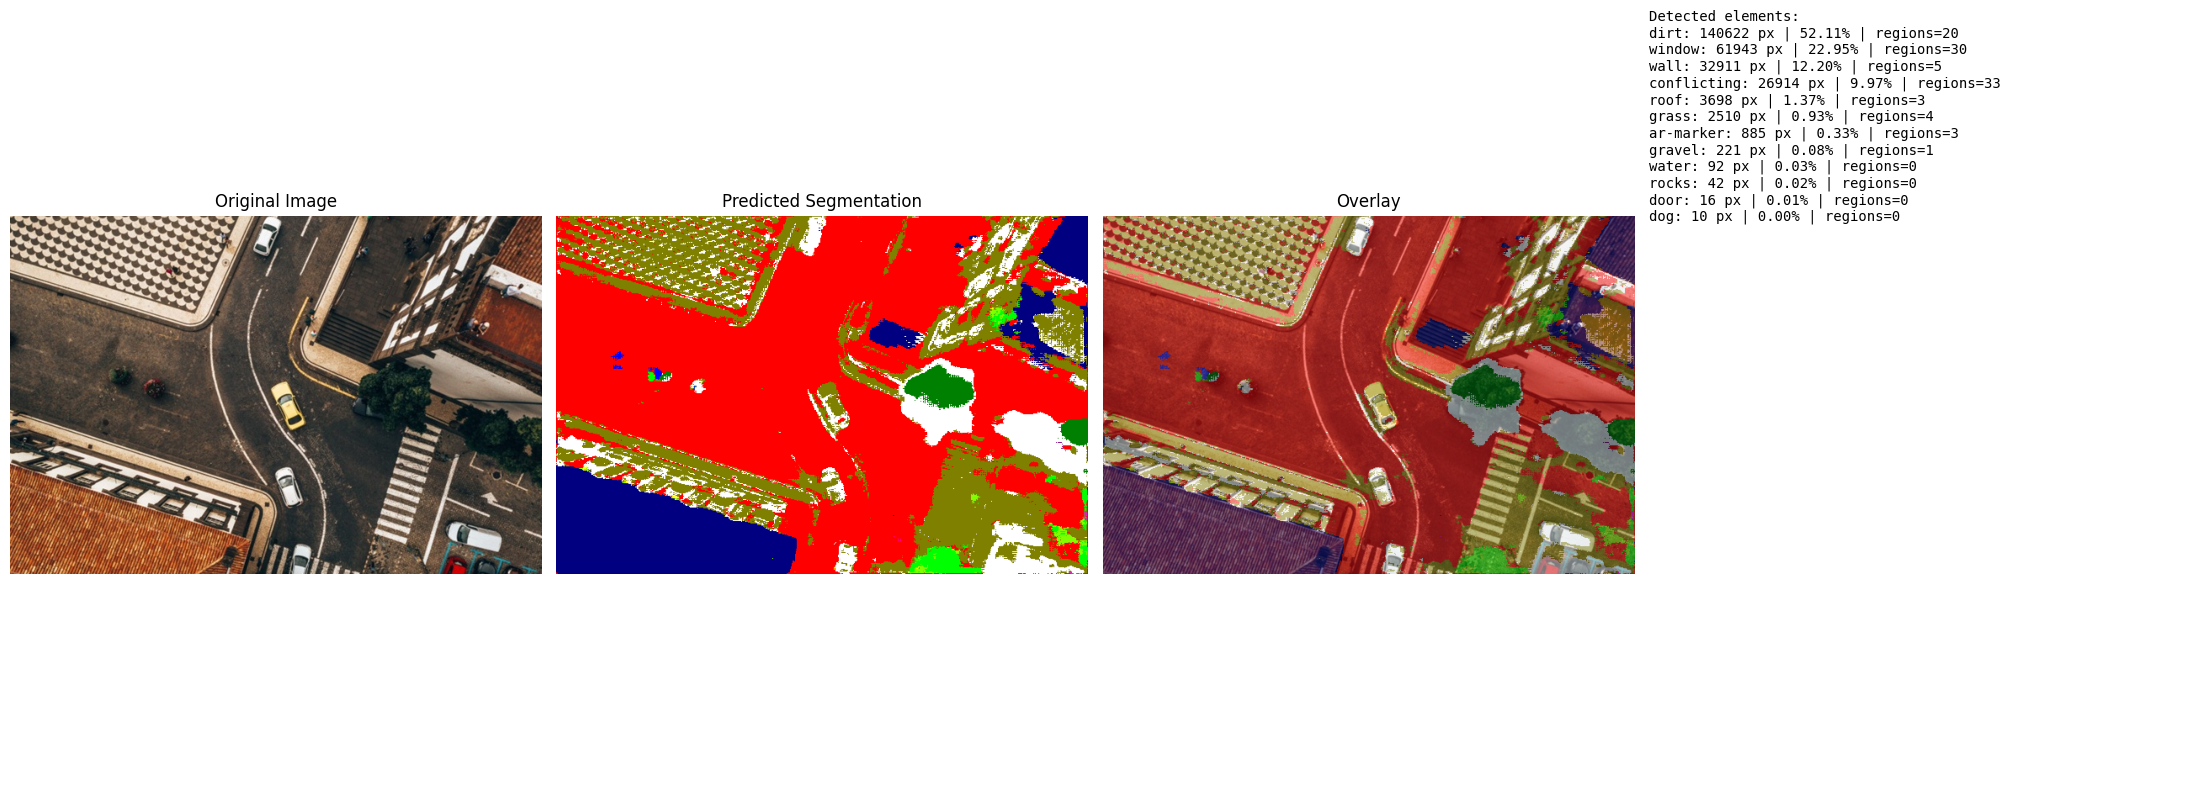

Saved CSV: ./predictions/test_aerial_stats.csv
Saved mask: ./predictions/test_aerial_mask.png
Saved overlay: ./predictions/test_aerial_overlay.png
Saved figure: ./predictions/test_aerial_summary.png
    class_id   class_name  pixels  percent  approx_regions
0          1         dirt  140622  52.1085              20
1         10       window   61943  22.9534              30
2          9         wall   32911  12.1954               5
3         22  conflicting   26914   9.9732              33
4          8         roof    3698   1.3703               3
5          2        grass    2510   0.9301               4
6         20    ar-marker     885   0.3279               3
7          3       gravel     221   0.0819               1
8          4        water      92   0.0341               0
9          5        rocks      42   0.0156               0
10        11         door      16   0.0059               0
11        15          dog      10   0.0037               0


In [3]:
image_path = "/content/test_aerial.jpg"
result = predict_and_visualize_image(
     image_path=image_path,
     model=teacher,          # or loaded_model
     id2name=id2name,
     id2code=id2code,
     target_size=input_size,
     min_region_pixels=80,
     ignore_background=True,
     normalize=True,
     save_dir=predictions_dir,
     show=True
 )
print(result["stats_df"])


In [4]:
result["stats_df"]

,class_id,class_name,pixels,percent,approx_regions
0,1,dirt,140622,52.1085,20
1,10,window,61943,22.9534,30
2,9,wall,32911,12.1954,5
3,22,conflicting,26914,9.9732,33
4,8,roof,3698,1.3703,3
5,2,grass,2510,0.9301,4
6,20,ar-marker,885,0.3279,3
7,3,gravel,221,0.0819,1
8,4,water,92,0.0341,0
9,5,rocks,42,0.0156,0


#**Mapping LLM**

In [5]:
from dataclasses import dataclass
import math
import random
import numpy as np


# ============================================================
# SEGMENTATION TOKENS
# Assumption:
#   class_map is a 2D class-id map aligned to the drone frame
#   with IMAGE TOP = DRONE FORWARD
# ============================================================
SEG_FRONT_TOKS = ["FRONT_BLOCKED", "FRONT_TIGHT", "FRONT_OPEN", "FRONT_WIDE"]
SEG_ROAD_TOKS = ["ROAD_MISSING", "ROAD_WEAK", "ROAD_PRESENT", "ROAD_STRONG"]
SEG_CURVE_TOKS = ["ROAD_LEFT", "ROAD_STRAIGHT", "ROAD_RIGHT"]
SEG_VEH_TOKS = ["VEH_NONE", "VEH_SPARSE", "VEH_NEAR"]
SEG_BUILD_TOKS = ["BLDG_FAR", "BLDG_NEAR"]
SEG_VEG_TOKS = ["VEG_FAR", "VEG_NEAR"]
SEG_XWALK_TOKS = ["XWALK_OFF", "XWALK_ON"]


# ============================================================
# BASE NAV TOKENS
# ============================================================
CLEAR_TOKS = ["CLEAR_CRIT", "CLEAR_LOW", "CLEAR_MID", "CLEAR_HIGH"]
HEAD_TOKS = ["GOAL_LEFT_HARD", "GOAL_LEFT", "GOAL_FRONT", "GOAL_RIGHT", "GOAL_RIGHT_HARD"]
LLM_TOKS = ["LLM_LEFT_HARD", "LLM_LEFT", "LLM_STRAIGHT", "LLM_RIGHT", "LLM_RIGHT_HARD"]
SPD_TOKS = ["SPD_LOW", "SPD_MID", "SPD_HIGH"]
RMSE_TOKS = ["RMSE_LOW", "RMSE_MID", "RMSE_HIGH"]
PROG_TOKS = ["MISSION_EARLY", "MISSION_MID", "MISSION_LATE"]
RISK_TOKS = ["RISK_LOW", "RISK_MID", "RISK_HIGH"]
GOAL_TOKS = ["GOAL_NEAR", "GOAL_MID", "GOAL_FAR"]


# ============================================================
# CONFIG
# ============================================================
@dataclass
class LLMPromptConfig:
    enable: bool = True
    every_steps: int = 8
    temperature: float = 0.70
    default_action: str = "ACT_KEEP"

    n_layer: int = 1
    n_embd: int = 24
    block_size: int = 18
    n_head: int = 4

    num_train_steps: int = 700
    learning_rate: float = 0.01
    beta1: float = 0.85
    beta2: float = 0.99
    eps_adam: float = 1e-8

    allowed_actions: tuple = (
        "ACT_KEEP",
        "ACT_SLOW",
        "ACT_FAST",
        "ACT_LEFT_BIAS",
        "ACT_RIGHT_BIAS",
        "ACT_LLM_MORE",
        "ACT_LLM_LESS",
        "ACT_SAFE_MODE",
    )

    slow_cap: float = 0.55
    fast_boost: float = 0.10
    safe_cap: float = 0.40
    steer_bias_deg: float = 10.0
    llm_delta: float = 0.12


# ============================================================
# SEGMENTATION HELPERS
# ============================================================
def _norm_label_name(s):
    return str(s).strip().lower().replace("-", " ").replace("_", " ")


def _find_ids_by_keywords(id2name, keywords):
    out = set()
    kws = [k.lower() for k in keywords]
    for cid, name in id2name.items():
        nm = _norm_label_name(name)
        if any(k in nm for k in kws):
            out.add(int(cid))
    return out


def _region_mask(h, w, y0f, y1f, x0f, x1f):
    y0 = max(0, min(h, int(round(y0f * h))))
    y1 = max(0, min(h, int(round(y1f * h))))
    x0 = max(0, min(w, int(round(x0f * w))))
    x1 = max(0, min(w, int(round(x1f * w))))
    m = np.zeros((h, w), dtype=bool)
    m[y0:y1, x0:x1] = True
    return m


def _frac_ids(class_map, ids_set, region_mask):
    if not ids_set:
        return 0.0
    vals = np.isin(class_map[region_mask], list(ids_set))
    if vals.size == 0:
        return 0.0
    return float(vals.mean())


def _bucket_front_open(free_front, obst_front):
    score = float(free_front) - 0.85 * float(obst_front)
    if score < 0.02:
        return "FRONT_BLOCKED"
    if score < 0.10:
        return "FRONT_TIGHT"
    if score < 0.22:
        return "FRONT_OPEN"
    return "FRONT_WIDE"


def _bucket_road_presence(road_front):
    r = float(road_front)
    if r < 0.03:
        return "ROAD_MISSING"
    if r < 0.10:
        return "ROAD_WEAK"
    if r < 0.22:
        return "ROAD_PRESENT"
    return "ROAD_STRONG"


def _bucket_road_curve(class_map, road_ids, upper_region_mask):
    if not road_ids:
        return "ROAD_STRAIGHT"

    road_mask = upper_region_mask & np.isin(class_map, list(road_ids))
    _, xs = np.where(road_mask)
    if xs.size < 10:
        return "ROAD_STRAIGHT"

    w = class_map.shape[1]
    mean_x = float(xs.mean())
    dx = (mean_x - 0.5 * (w - 1)) / max(float(w), 1.0)

    if dx < -0.10:
        return "ROAD_LEFT"
    if dx > 0.10:
        return "ROAD_RIGHT"
    return "ROAD_STRAIGHT"


def _bucket_vehicle(veh_front):
    v = float(veh_front)
    if v < 0.01:
        return "VEH_NONE"
    if v < 0.04:
        return "VEH_SPARSE"
    return "VEH_NEAR"


def _bucket_binary_near(frac_val, tok_far, tok_near, th=0.03):
    return tok_near if float(frac_val) >= float(th) else tok_far


def build_segmentation_nav_prompt_tokens(class_map, id2name):
    class_map = np.asarray(class_map)
    if class_map.ndim != 2:
        raise ValueError("class_map must be a 2D class-id array.")

    h, w = class_map.shape

    front_center = _region_mask(h, w, 0.00, 0.45, 0.25, 0.75)
    upper_all = _region_mask(h, w, 0.00, 0.60, 0.00, 1.00)
    side_bands = _region_mask(h, w, 0.05, 0.85, 0.00, 0.18) | _region_mask(h, w, 0.05, 0.85, 0.82, 1.00)
    front_sides = _region_mask(h, w, 0.00, 0.55, 0.00, 0.25) | _region_mask(h, w, 0.00, 0.55, 0.75, 1.00)
    cross_region = _region_mask(h, w, 0.00, 0.70, 0.15, 0.85)

    road_ids = _find_ids_by_keywords(id2name, ["road", "street", "lane", "asphalt", "highway", "drive"])
    traversable_ids = set(road_ids) | _find_ids_by_keywords(
        id2name, ["sidewalk", "crosswalk", "pavement", "ground", "floor", "path"]
    )
    vehicle_ids = _find_ids_by_keywords(id2name, ["car", "vehicle", "truck", "bus", "van", "motorcycle", "bike"])
    building_ids = _find_ids_by_keywords(id2name, ["building", "house", "wall", "facade", "roof"])
    vegetation_ids = _find_ids_by_keywords(id2name, ["tree", "vegetation", "grass", "bush", "plant"])
    person_ids = _find_ids_by_keywords(id2name, ["person", "pedestrian", "human"])
    pole_ids = _find_ids_by_keywords(id2name, ["pole", "fence", "barrier", "sign"])
    crosswalk_ids = _find_ids_by_keywords(id2name, ["crosswalk", "zebra"])

    obstacle_ids = set(vehicle_ids) | set(building_ids) | set(vegetation_ids) | set(person_ids) | set(pole_ids)

    free_front = _frac_ids(class_map, traversable_ids, front_center)
    obst_front = _frac_ids(class_map, obstacle_ids, front_center)
    road_front = _frac_ids(class_map, road_ids, front_center)
    veh_front = _frac_ids(class_map, vehicle_ids, front_center)
    bld_side = _frac_ids(class_map, building_ids, side_bands)
    veg_side = _frac_ids(class_map, vegetation_ids, front_sides)
    xwalk_frac = _frac_ids(class_map, crosswalk_ids, cross_region)

    return [
        _bucket_front_open(free_front, obst_front),
        _bucket_road_presence(road_front),
        _bucket_road_curve(class_map, road_ids, upper_all),
        _bucket_vehicle(veh_front),
        _bucket_binary_near(bld_side, "BLDG_FAR", "BLDG_NEAR", th=0.03),
        _bucket_binary_near(veg_side, "VEG_FAR", "VEG_NEAR", th=0.03),
        _bucket_binary_near(xwalk_frac, "XWALK_OFF", "XWALK_ON", th=0.01),
    ]


# ============================================================
# BASE BUCKETS
# ============================================================
def _llm_bucket_clearance(c):
    c = float(c)
    if c < 0.05:
        return "CLEAR_CRIT"
    if c < 0.20:
        return "CLEAR_LOW"
    if c < 0.50:
        return "CLEAR_MID"
    return "CLEAR_HIGH"


def _llm_bucket_heading(h_deg):
    h = float(h_deg)
    if h < -25.0:
        return "GOAL_LEFT_HARD"
    if h < -8.0:
        return "GOAL_LEFT"
    if h > 25.0:
        return "GOAL_RIGHT_HARD"
    if h > 8.0:
        return "GOAL_RIGHT"
    return "GOAL_FRONT"


def _llm_bucket_llm_steer(s_deg):
    s = float(s_deg)
    if s < -20.0:
        return "LLM_LEFT_HARD"
    if s < -5.0:
        return "LLM_LEFT"
    if s > 20.0:
        return "LLM_RIGHT_HARD"
    if s > 5.0:
        return "LLM_RIGHT"
    return "LLM_STRAIGHT"


def _llm_bucket_speed_scale(s):
    s = float(s)
    if s < 0.45:
        return "SPD_LOW"
    if s < 0.80:
        return "SPD_MID"
    return "SPD_HIGH"


def _llm_bucket_rmse(r):
    r = float(r)
    if r < 0.15:
        return "RMSE_LOW"
    if r < 0.40:
        return "RMSE_MID"
    return "RMSE_HIGH"


def _llm_bucket_progress(seg_i, num_wps):
    frac = float(seg_i) / float(max(num_wps - 1, 1))
    if frac < 0.33:
        return "MISSION_EARLY"
    if frac < 0.66:
        return "MISSION_MID"
    return "MISSION_LATE"


def _llm_bucket_risk(cur_clear):
    c = float(cur_clear)
    if c < 0.05:
        return "RISK_HIGH"
    if c < 0.20:
        return "RISK_MID"
    return "RISK_LOW"


def _llm_bucket_goal_dist(dist_to_goal):
    d = float(dist_to_goal)
    if d < 0.35:
        return "GOAL_NEAR"
    if d < 1.00:
        return "GOAL_MID"
    return "GOAL_FAR"


# ============================================================
# PROMPT BUILDERS
# ============================================================
def build_llm_nav_prompt_tokens(
    dist_to_goal,
    cur_clear,
    heading_err_deg,
    last_llm,
    rmse_now,
    seg_i,
    num_wps,
    class_map=None,
    id2name=None,
    seg_prompt_tokens=None,
):
    steer_deg = float(last_llm.get("steer_deg", 0.0))
    speed_scale = float(last_llm.get("speed_scale", 1.0))

    toks = [
        _llm_bucket_clearance(cur_clear),
        _llm_bucket_heading(heading_err_deg),
        _llm_bucket_llm_steer(steer_deg),
        _llm_bucket_speed_scale(speed_scale),
        _llm_bucket_rmse(rmse_now),
        _llm_bucket_progress(seg_i, num_wps),
        _llm_bucket_risk(cur_clear),
        _llm_bucket_goal_dist(dist_to_goal),
    ]

    if seg_prompt_tokens is None and class_map is not None and id2name is not None:
        seg_prompt_tokens = build_segmentation_nav_prompt_tokens(class_map, id2name)

    if seg_prompt_tokens:
        toks.extend(list(seg_prompt_tokens))

    return toks


def build_llm_navigation_prompt_text(prompt_tokens):
    return (
        "You are a UAV navigation agent in a GPS-denied environment.\n"
        "Use the semantic navigation state below to choose one safe high-level action.\n\n"
        f"PROMPT_TOKENS:\n{' '.join(prompt_tokens)}\n\n"
        "AVAILABLE_ACTIONS:\n"
        "ACT_KEEP\n"
        "ACT_SLOW\n"
        "ACT_FAST\n"
        "ACT_LEFT_BIAS\n"
        "ACT_RIGHT_BIAS\n"
        "ACT_LLM_MORE\n"
        "ACT_LLM_LESS\n"
        "ACT_SAFE_MODE\n\n"
        "Return only the best action token."
    )


def build_llm_navigation_prompt(
    dist_to_goal,
    cur_clear,
    heading_err_deg,
    last_llm,
    rmse_now,
    seg_i,
    num_wps,
    class_map=None,
    id2name=None,
    seg_prompt_tokens=None,
):
    prompt_tokens = build_llm_nav_prompt_tokens(
        dist_to_goal=dist_to_goal,
        cur_clear=cur_clear,
        heading_err_deg=heading_err_deg,
        last_llm=last_llm,
        rmse_now=rmse_now,
        seg_i=seg_i,
        num_wps=num_wps,
        class_map=class_map,
        id2name=id2name,
        seg_prompt_tokens=seg_prompt_tokens,
    )
    prompt_text = build_llm_navigation_prompt_text(prompt_tokens)
    return prompt_tokens, prompt_text


# ============================================================
# EXPERT DOCS
# ============================================================
def _expert_action_from_prompt_tokens(tokens):
    clear_tok = tokens[0]
    head_tok = tokens[1]
    llm_tok = tokens[2]
    spd_tok = tokens[3]
    rmse_tok = tokens[4]
    prog_tok = tokens[5]
    risk_tok = tokens[6]
    goal_tok = tokens[7]
    extra = set(tokens[8:])

    if "FRONT_BLOCKED" in extra or "ROAD_MISSING" in extra:
        return "ACT_SAFE_MODE"

    if "VEH_NEAR" in extra or "XWALK_ON" in extra:
        return "ACT_SLOW"

    if "BLDG_NEAR" in extra and clear_tok in ("CLEAR_CRIT", "CLEAR_LOW"):
        return "ACT_SAFE_MODE"

    if "FRONT_TIGHT" in extra:
        if "ROAD_LEFT" in extra and head_tok not in ("GOAL_RIGHT", "GOAL_RIGHT_HARD"):
            return "ACT_LEFT_BIAS"
        if "ROAD_RIGHT" in extra and head_tok not in ("GOAL_LEFT", "GOAL_LEFT_HARD"):
            return "ACT_RIGHT_BIAS"
        return "ACT_SLOW"

    if "ROAD_LEFT" in extra and head_tok in ("GOAL_LEFT_HARD", "GOAL_LEFT", "GOAL_FRONT"):
        return "ACT_LEFT_BIAS"

    if "ROAD_RIGHT" in extra and head_tok in ("GOAL_RIGHT_HARD", "GOAL_RIGHT", "GOAL_FRONT"):
        return "ACT_RIGHT_BIAS"

    if clear_tok == "CLEAR_CRIT" or risk_tok == "RISK_HIGH":
        return "ACT_SAFE_MODE"

    if clear_tok == "CLEAR_LOW":
        if "LEFT" in head_tok:
            return "ACT_LEFT_BIAS"
        if "RIGHT" in head_tok:
            return "ACT_RIGHT_BIAS"
        return "ACT_SLOW"

    if rmse_tok == "RMSE_HIGH":
        return "ACT_LLM_MORE"

    if clear_tok == "CLEAR_HIGH" and rmse_tok == "RMSE_LOW" and spd_tok == "SPD_HIGH":
        if llm_tok == "LLM_STRAIGHT":
            return "ACT_KEEP"
        return "ACT_LLM_LESS"

    if prog_tok == "MISSION_LATE" and goal_tok == "GOAL_NEAR":
        return "ACT_SLOW"

    return "ACT_KEEP"


def build_default_llm_prompt_docs(num_docs=800, seed=7):
    rng = random.Random(seed)
    docs = []

    for _ in range(int(num_docs)):
        toks = [
            rng.choice(CLEAR_TOKS),
            rng.choice(HEAD_TOKS),
            rng.choice(LLM_TOKS),
            rng.choice(SPD_TOKS),
            rng.choice(RMSE_TOKS),
            rng.choice(PROG_TOKS),
            rng.choice(RISK_TOKS),
            rng.choice(GOAL_TOKS),
            rng.choice(SEG_FRONT_TOKS),
            rng.choice(SEG_ROAD_TOKS),
            rng.choice(SEG_CURVE_TOKS),
            rng.choice(SEG_VEH_TOKS),
            rng.choice(SEG_BUILD_TOKS),
            rng.choice(SEG_VEG_TOKS),
            rng.choice(SEG_XWALK_TOKS),
        ]
        action = _expert_action_from_prompt_tokens(toks)
        docs.append(" ".join(toks + [action]))

    return docs


# ============================================================
# SCALAR AUTOGRAD
# ============================================================
class Value:
    __slots__ = ("data", "grad", "_children", "_local_grads")

    def __init__(self, data, children=(), local_grads=()):
        if isinstance(data, Value):
            data = data.data
        self.data = float(data)
        self.grad = 0.0
        self._children = children
        self._local_grads = tuple(
            float(g.data) if isinstance(g, Value) else float(g)
            for g in local_grads
        )

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        return Value(self.data + other.data, (self, other), (1.0, 1.0))

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        return Value(self.data * other.data, (self, other), (other.data, self.data))

    def __pow__(self, other):
        other = float(other)
        return Value(self.data ** other, (self,), (other * (self.data ** (other - 1)),))

    def log(self):
        x = max(self.data, 1e-12)
        return Value(math.log(x), (self,), (1.0 / x,))

    def exp(self):
        ex = math.exp(float(self.data))
        return Value(ex, (self,), (ex,))

    def relu(self):
        return Value(max(0.0, self.data), (self,), (1.0 if self.data > 0.0 else 0.0,))

    def __neg__(self): return self * -1.0
    def __radd__(self, other): return self + other
    def __sub__(self, other): return self + (-other)
    def __rsub__(self, other): return other + (-self)
    def __rmul__(self, other): return self * other
    def __truediv__(self, other): return self * (other ** -1)
    def __rtruediv__(self, other): return other * (self ** -1)

    def backward(self):
        topo = []
        visited = set()

        def build(v):
            if id(v) not in visited:
                visited.add(id(v))
                for child in v._children:
                    build(child)
                topo.append(v)

        build(self)
        self.grad = 1.0

        for v in reversed(topo):
            for child, local_grad in zip(v._children, v._local_grads):
                child.grad += float(local_grad) * float(v.grad)


# ============================================================
# TINY GPT PROMPT MODEL
# ============================================================
class TinyGPTPromptModel:
    def __init__(self, docs, n_layer=1, n_embd=24, block_size=18, n_head=4):
        self.docs = [d.split() for d in docs]
        self.BOS_TOKEN = "<BOS>"

        vocab = sorted(set(tok for doc in self.docs for tok in doc) | {self.BOS_TOKEN})
        self.stoi = {tok: i for i, tok in enumerate(vocab)}
        self.itos = {i: tok for tok, i in self.stoi.items()}
        self.vocab_size = len(vocab)
        self.BOS = self.stoi[self.BOS_TOKEN]

        self.n_layer = int(n_layer)
        self.n_embd = int(n_embd)
        self.block_size = int(block_size)
        self.n_head = int(n_head)
        self.head_dim = self.n_embd // self.n_head

        def matrix(nout, nin, std=0.08):
            return [[Value(random.gauss(0, std)) for _ in range(nin)] for _ in range(nout)]

        self.state_dict = {
            "wte": matrix(self.vocab_size, self.n_embd),
            "wpe": matrix(self.block_size, self.n_embd),
            "lm_head": matrix(self.vocab_size, self.n_embd),
        }
        for i in range(self.n_layer):
            self.state_dict[f"layer{i}.attn_wq"] = matrix(self.n_embd, self.n_embd)
            self.state_dict[f"layer{i}.attn_wk"] = matrix(self.n_embd, self.n_embd)
            self.state_dict[f"layer{i}.attn_wv"] = matrix(self.n_embd, self.n_embd)
            self.state_dict[f"layer{i}.attn_wo"] = matrix(self.n_embd, self.n_embd)
            self.state_dict[f"layer{i}.mlp_fc1"] = matrix(4 * self.n_embd, self.n_embd)
            self.state_dict[f"layer{i}.mlp_fc2"] = matrix(self.n_embd, 4 * self.n_embd)

        self.params = [p for mat in self.state_dict.values() for row in mat for p in row]

    def linear(self, x, w):
        return [sum((wi * xi for wi, xi in zip(wo, x)), Value(0.0)) for wo in w]

    def softmax(self, logits):
        max_val = max(float(v.data) for v in logits)
        exps = [(v - max_val).exp() for v in logits]
        total = sum(exps, Value(0.0))
        return [e / total for e in exps]

    def rmsnorm(self, x):
        ms = sum((xi * xi for xi in x), Value(0.0)) / len(x)
        scale = (ms + 1e-5) ** -0.5
        return [xi * scale for xi in x]

    def gpt(self, token_id, pos_id, keys, values):
        pos_id = int(min(pos_id, self.block_size - 1))

        tok_emb = self.state_dict["wte"][token_id]
        pos_emb = self.state_dict["wpe"][pos_id]
        x = [t + p for t, p in zip(tok_emb, pos_emb)]
        x = self.rmsnorm(x)

        for li in range(self.n_layer):
            x_res = x
            x = self.rmsnorm(x)

            q = self.linear(x, self.state_dict[f"layer{li}.attn_wq"])
            k = self.linear(x, self.state_dict[f"layer{li}.attn_wk"])
            v = self.linear(x, self.state_dict[f"layer{li}.attn_wv"])

            keys[li].append(k)
            values[li].append(v)

            x_attn = []
            for h in range(self.n_head):
                hs = h * self.head_dim
                q_h = q[hs:hs + self.head_dim]
                k_h = [ki[hs:hs + self.head_dim] for ki in keys[li]]
                v_h = [vi[hs:hs + self.head_dim] for vi in values[li]]

                attn_logits = [
                    sum((q_h[j] * k_h[t][j] for j in range(self.head_dim)), Value(0.0)) / (self.head_dim ** 0.5)
                    for t in range(len(k_h))
                ]

                attn_w = self.softmax(attn_logits)
                head_out = [
                    sum((attn_w[t] * v_h[t][j] for t in range(len(v_h))), Value(0.0))
                    for j in range(self.head_dim)
                ]
                x_attn.extend(head_out)

            x = self.linear(x_attn, self.state_dict[f"layer{li}.attn_wo"])
            x = [a + b for a, b in zip(x, x_res)]

            x_res = x
            x = self.rmsnorm(x)
            x = self.linear(x, self.state_dict[f"layer{li}.mlp_fc1"])
            x = [xi.relu() for xi in x]
            x = self.linear(x, self.state_dict[f"layer{li}.mlp_fc2"])
            x = [a + b for a, b in zip(x, x_res)]

        return self.linear(x, self.state_dict["lm_head"])

    def train_model(self, num_steps=700, learning_rate=0.01, beta1=0.85, beta2=0.99, eps_adam=1e-8, verbose=True):
        m = [0.0] * len(self.params)
        v = [0.0] * len(self.params)

        for step in range(int(num_steps)):
            doc = self.docs[step % len(self.docs)]
            toks = [self.BOS] + [self.stoi[t] for t in doc]
            n = min(self.block_size, len(toks) - 1)

            keys = [[] for _ in range(self.n_layer)]
            values = [[] for _ in range(self.n_layer)]
            losses = []

            for pos_id in range(n):
                token_id = toks[pos_id]
                target_id = toks[pos_id + 1]
                logits = self.gpt(token_id, pos_id, keys, values)
                probs = self.softmax(logits)
                losses.append(-probs[target_id].log())

            loss = (1.0 / max(n, 1)) * sum(losses, Value(0.0))
            loss.backward()

            lr_t = learning_rate * (1.0 - step / max(int(num_steps), 1))
            for i, p in enumerate(self.params):
                m[i] = beta1 * m[i] + (1.0 - beta1) * p.grad
                v[i] = beta2 * v[i] + (1.0 - beta2) * (p.grad ** 2)
                m_hat = m[i] / (1.0 - beta1 ** (step + 1))
                v_hat = v[i] / (1.0 - beta2 ** (step + 1))
                p.data -= lr_t * m_hat / (v_hat ** 0.5 + eps_adam)
                p.grad = 0.0

            if verbose and ((step + 1) % 100 == 0 or step == 0 or step == num_steps - 1):
                print(f"[TinyGPTPromptModel] step {step+1:4d}/{num_steps:4d} | loss {loss.data:.4f}")

    def predict_action(self, prompt_tokens, allowed_actions, temperature=0.70, default_action="ACT_KEEP"):
        ids = [self.BOS] + [self.stoi[t] for t in prompt_tokens if t in self.stoi]
        ids = ids[-self.block_size:]

        keys = [[] for _ in range(self.n_layer)]
        values = [[] for _ in range(self.n_layer)]

        logits = None
        for pos_id, token_id in enumerate(ids):
            logits = self.gpt(token_id, pos_id, keys, values)

        if logits is None:
            return default_action, {"prompt_tokens": list(prompt_tokens), "action_probabilities": {}}

        probs = self.softmax([l / float(max(temperature, 1e-6)) for l in logits])
        valid = [a for a in allowed_actions if a in self.stoi]

        if not valid:
            return default_action, {"prompt_tokens": list(prompt_tokens), "action_probabilities": {}}

        best_action = max(valid, key=lambda a: probs[self.stoi[a]].data)
        return best_action, {
            "prompt_tokens": list(prompt_tokens),
            "action_token": best_action,
            "action_probabilities": {a: float(probs[self.stoi[a]].data) for a in valid},
        }


# ============================================================
# AGENT
# ============================================================
class LLMPromptNavAgent:
    def __init__(self, cfg: LLMPromptConfig, prompt_docs=None, verbose=True):
        self.cfg = cfg
        docs = prompt_docs if prompt_docs is not None else build_default_llm_prompt_docs()

        self.model = TinyGPTPromptModel(
            docs=docs,
            n_layer=cfg.n_layer,
            n_embd=cfg.n_embd,
            block_size=cfg.block_size,
            n_head=cfg.n_head,
        )
        self.model.train_model(
            num_steps=cfg.num_train_steps,
            learning_rate=cfg.learning_rate,
            beta1=cfg.beta1,
            beta2=cfg.beta2,
            eps_adam=cfg.eps_adam,
            verbose=verbose,
        )

    def predict_from_state(
        self,
        dist_to_goal,
        cur_clear,
        heading_err_deg,
        last_llm,
        rmse_now,
        seg_i,
        num_wps,
        class_map=None,
        id2name=None,
        seg_prompt_tokens=None,
    ):
        prompt_tokens, prompt_text = build_llm_navigation_prompt(
            dist_to_goal=dist_to_goal,
            cur_clear=cur_clear,
            heading_err_deg=heading_err_deg,
            last_llm=last_llm,
            rmse_now=rmse_now,
            seg_i=seg_i,
            num_wps=num_wps,
            class_map=class_map,
            id2name=id2name,
            seg_prompt_tokens=seg_prompt_tokens,
        )

        action, meta = self.model.predict_action(
            prompt_tokens=prompt_tokens,
            allowed_actions=self.cfg.allowed_actions,
            temperature=self.cfg.temperature,
            default_action=self.cfg.default_action,
        )

        meta["prompt_text"] = prompt_text
        return action, meta


# ============================================================
# ACTION APPLICATION
# ============================================================
def apply_llm_action_to_nav(action_tok, dynamic_llm_weight, rl_speed_cap, rl_steer_deg, cfg):
    llm_cfg = cfg.llm_cfg

    dynamic_llm_weight = float(dynamic_llm_weight)
    rl_speed_cap = float(rl_speed_cap)
    rl_steer_deg = float(rl_steer_deg)

    if action_tok == "ACT_SLOW":
        rl_speed_cap = min(rl_speed_cap, float(llm_cfg.slow_cap))

    elif action_tok == "ACT_FAST":
        rl_speed_cap = min(1.0, rl_speed_cap + float(llm_cfg.fast_boost))

    elif action_tok == "ACT_LEFT_BIAS":
        rl_steer_deg -= float(llm_cfg.steer_bias_deg)

    elif action_tok == "ACT_RIGHT_BIAS":
        rl_steer_deg += float(llm_cfg.steer_bias_deg)

    elif action_tok == "ACT_LLM_MORE":
        rlpg_cfg = getattr(cfg, "rlpg_cfg", None)
        llm_w_max = float(getattr(rlpg_cfg, "llm_w_max", 1.0))
        dynamic_llm_weight = min(llm_w_max, dynamic_llm_weight + float(llm_cfg.llm_delta))

    elif action_tok == "ACT_LLM_LESS":
        dynamic_llm_weight = max(0.0, dynamic_llm_weight - float(llm_cfg.llm_delta))

    elif action_tok == "ACT_SAFE_MODE":
        rl_speed_cap = min(rl_speed_cap, float(llm_cfg.safe_cap))
        dynamic_llm_weight = 0.0
        rl_steer_deg = 0.0

    return dynamic_llm_weight, rl_speed_cap, rl_steer_deg

def extract_pred_seg_class_map(result):
    """
    Extract HxW integer class-id map from segmentation result dict.
    """

    # direct class-id map keys
    direct_keys = [
        "pred_seg_class_map",
        "pred_mask",
        "label_map",
        "class_map",
        "pred_ids",
        "pred_classes",
    ]

    for k in direct_keys:
        if k in result and result[k] is not None:
            arr = np.asarray(result[k])
            if arr.ndim == 2:
                return arr.astype(np.int32)

    # logits / probabilities
    prob_keys = [
        "pred_logits",
        "pred_probs",
        "prob_map",
        "softmax",
        "pred_all",
    ]

    for k in prob_keys:
        if k in result and result[k] is not None:
            arr = np.asarray(result[k])

            # H x W x C
            if arr.ndim == 3 and arr.shape[-1] > 1:
                return np.argmax(arr, axis=-1).astype(np.int32)

            # C x H x W
            if arr.ndim == 3 and arr.shape[0] > 1:
                return np.argmax(arr, axis=0).astype(np.int32)

    raise ValueError(
        "Could not find a class-id segmentation map in result. "
        "Add a key such as result['pred_mask'] or result['pred_seg_class_map'] "
        "inside predict_and_visualize_image()."
    )

In [8]:
llm_cfg = LLMPromptConfig()
agent = LLMPromptNavAgent(llm_cfg, verbose=False)
pred_seg_class_map = result["pred_class_map"]

action, meta = agent.predict_from_state(
    dist_to_goal=1.8,
    cur_clear=0.32,
    heading_err_deg=-12.0,
    last_llm={"steer_deg": -4.0, "speed_scale": 0.75},
    rmse_now=0.11,
    seg_i=3,
    num_wps=23,
    class_map=pred_seg_class_map,   # HxW integer segmentation map
    id2name=id2name,                # {0:"background", 1:"road", 2:"car", ...}
)

print("ACTION:", action)
print("TOKENS:", meta["prompt_tokens"])
print("PROMPT:\n", meta["prompt_text"])

ACTION: ACT_SAFE_MODE
TOKENS: ['CLEAR_MID', 'GOAL_LEFT', 'LLM_STRAIGHT', 'SPD_MID', 'RMSE_LOW', 'MISSION_EARLY', 'RISK_LOW', 'GOAL_FAR', 'FRONT_BLOCKED', 'ROAD_MISSING', 'ROAD_STRAIGHT', 'VEH_NONE', 'BLDG_NEAR', 'VEG_FAR', 'XWALK_OFF']
PROMPT:
 You are a UAV navigation agent in a GPS-denied environment.
Use the semantic navigation state below to choose one safe high-level action.

PROMPT_TOKENS:
CLEAR_MID GOAL_LEFT LLM_STRAIGHT SPD_MID RMSE_LOW MISSION_EARLY RISK_LOW GOAL_FAR FRONT_BLOCKED ROAD_MISSING ROAD_STRAIGHT VEH_NONE BLDG_NEAR VEG_FAR XWALK_OFF

AVAILABLE_ACTIONS:
ACT_KEEP
ACT_SLOW
ACT_FAST
ACT_LEFT_BIAS
ACT_RIGHT_BIAS
ACT_LLM_MORE
ACT_LLM_LESS
ACT_SAFE_MODE

Return only the best action token.
